<a href="https://colab.research.google.com/github/prithikakalyan/prithikakalyan/blob/main/credit_risk_data_exercise.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BUAN 3301 — AI in Business
## Exercise 1, Q4: Credit-Risk Data Exercise

#### Complete the TODO cells in this notebook and use the outputs to answer Q4 in the Word handout. Follow either Option 1 or Option 2 in the Word handout to make credit_risk_dataset.csv accessible in Google Colab.

In [ ]:
# Run this setup cell first.
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_recall_fscore_support,
)

RANDOM_STATE = 10


## Colab / folder setup

If you are using Option 2 (uploading the file through Google Drive) to load the dataset, run the following cell. If you are using Option 1 (uploading the CSV directly to Google Colab), you can skip this cell.


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# TODO 0.1: Enter the path to credit_risk_dataset.csv below. It depends on the Colab setup option you selected in the Word handout.
DATA_PATH = '/content/credit_risk_dataset.csv'
df = pd.read_csv(DATA_PATH)

## Step 0: Load the dataset (1 mark)

Load and inspect the supplied credit-risk dataset. Show the attributes (column names), the number of rows and columns, and basic dataset information.


In [ ]:
# Inspect the dataset.
print("Columns:")
print(df.columns)

print("\nNumber of rows and columns:")
print(df.shape)

# TODO 0.2: Write ONE line below to display the dataset information.
print("\nBasic dataset information:")



Columns:
Index(['person_age', 'person_income', 'person_home_ownership',
       'person_emp_length', 'loan_intent', 'loan_grade', 'loan_amnt',
       'loan_int_rate', 'loan_percent_income', 'cb_person_default_on_file',
       'cb_person_cred_hist_length', 'default_status'],
      dtype='object')

Number of rows and columns:
(32581, 12)

Basic dataset information:


## Step 1: Attribute summary (1 mark)

Using the `default_status` class attribute, determine whether the dataset is imbalanced. If it is, identify which class has higher representation.

Report the class counts and percentages.


In [ ]:
# TODO 1.1: Identify the target column.
TARGET = "default_status"

class_counts = df[TARGET].value_counts()
class_percentages = df[TARGET].value_counts(normalize=True).mul(100)

print("Class counts:")
print(class_counts)

print("\nClass percentages:")
print(class_percentages.round(2))


Class counts:
default_status
Paid       25473
Default     7108
Name: count, dtype: int64

Class percentages:
default_status
Paid       78.18
Default    21.82
Name: proportion, dtype: float64


## Step 2: Feature (attribute) visualization (2 marks)

Investigate the relationship between `variable_of_interest` and `default_status`.

The code below produces two complementary pieces of evidence:

- **Group summary:** for each `default_status` class, it reports the count, mean, median, standard deviation, minimum, and maximum of `variable_of_interest`. This gives a numerical comparison of the two groups.
- **Boxplot:** visually compares the distributions of `variable_of_interest` across the two classes, especially their medians, spread, and unusual/extreme observations.

Use the group summary and the **“Loan Percent Income by Default Status”** boxplot to support your answer. Paste one screenshot containing both into the Word handout.


                count      mean  median       std   min   max
default_status                                               
Default          7108  0.246889    0.24  0.132148  0.01  0.78
Paid            25473  0.148805    0.13  0.087252  0.00  0.83


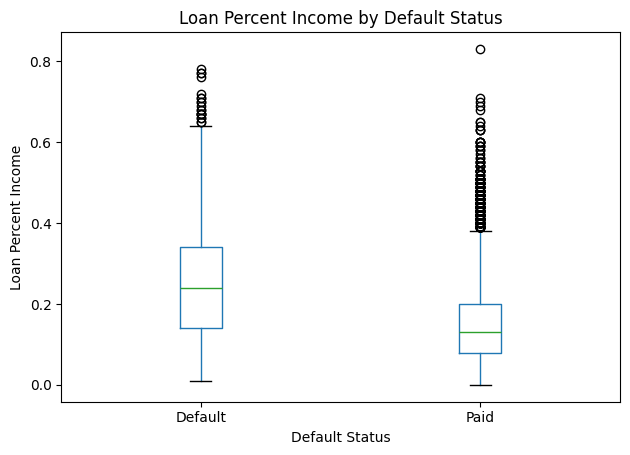

In [ ]:
# TODO 2.1: Identify the variable of interest named in the question.
variable_of_interest = "loan_percent_income"

feature_summary = df.groupby(TARGET)[variable_of_interest].agg(
    ["count", "mean", "median", "std", "min", "max"]
)
print(feature_summary)

ax = df.boxplot(column=variable_of_interest, by=TARGET, grid=False)
ax.set_title("Loan Percent Income by Default Status")
plt.suptitle("")
ax.set_xlabel("Default Status")
ax.set_ylabel("Loan Percent Income")
plt.tight_layout()
plt.show()


## Step 3: Building the classification model (2 marks)

Build a decision-tree classifier using **80% of the data for training** and the remaining **20% for testing**.

Requirements:
- use a gini impurity based `DecisionTreeClassifier`;
- use `random_state=10`;
- preserve target-class proportions when making the split;
- convert categorical predictors to a numeric representation as needed;
- display enough of the tree to make the root split readable;
- state the **root variable** and whether Step 2 gave you a reason to anticipate it.


In [ ]:
# Separate predictors (X) from the target (y).
X = df.drop(columns=[TARGET])
y = df[TARGET]

# Convert categorical predictors into numeric indicator variables.
X = pd.get_dummies(X, drop_first=False)

print("Predictor matrix shape:", X.shape)
X.head()


Predictor matrix shape: (32581, 26)


,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,person_home_ownership_MORTGAGE,person_home_ownership_OTHER,person_home_ownership_OWN,...,loan_intent_VENTURE,loan_grade_A,loan_grade_B,loan_grade_C,loan_grade_D,loan_grade_E,loan_grade_F,loan_grade_G,cb_person_default_on_file_N,cb_person_default_on_file_Y
0,22,59000,123.0,35000,16.02,0.59,3,False,False,False,...,False,False,False,False,True,False,False,False,False,True
1,21,9600,5.0,1000,11.14,0.10,2,False,False,True,...,False,False,True,False,False,False,False,False,True,False
2,25,9600,1.0,5500,12.87,0.57,3,True,False,False,...,False,False,False,True,False,False,False,False,True,False
3,23,65500,4.0,35000,15.23,0.53,2,False,False,False,...,False,False,False,True,False,False,False,False,True,False
4,24,54400,8.0,35000,14.27,0.55,4,False,False,False,...,False,False,False,True,False,False,False,False,False,True


In [ ]:
# TODO 3.1: Use 20% of the data as the test set.
test_percentage = 0.20

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=test_percentage,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (26064, 26)
Testing set size: (6517, 26)


In [ ]:
# TODO 3.2: Complete the decision-tree criterion.
tree_model = DecisionTreeClassifier(
    criterion="gini",
    random_state=RANDOM_STATE
)

# TODO 3.3: Fill in the blanks below to fit tree_model using the training data.

tree_model.fit(X_train, y_train)
print("Model fitted.")

Model fitted.


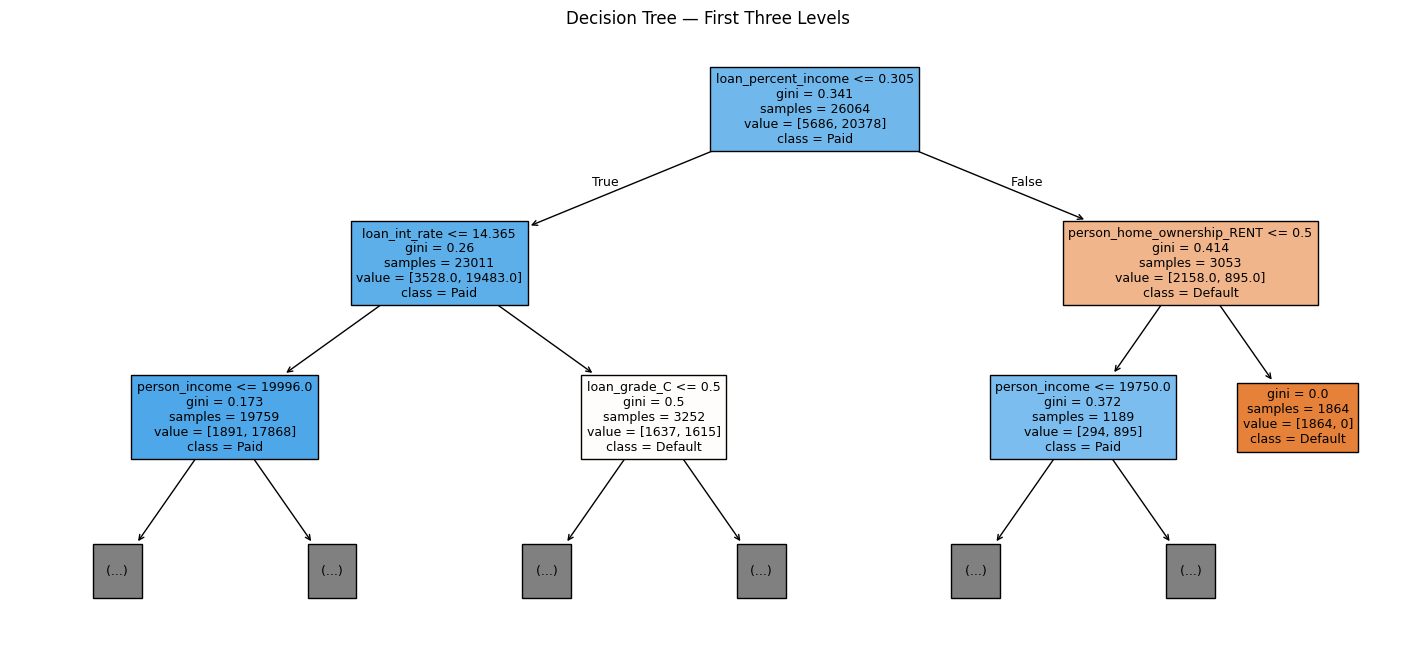

In [ ]:
# Display the first few levels of the fitted decision tree.
plt.figure(figsize=(18, 8))

plot_tree(
    tree_model,
    feature_names=X.columns,
    class_names=[str(c) for c in tree_model.classes_],
    filled=True,
    max_depth=2,
    fontsize=9
)

plt.title("Decision Tree — First Three Levels")
plt.show()


### Step 3 interpretation

The root variable is the variable used in the top (first) split of the tree. State it in the Word handout and briefly compare it with the Step 2 evidence.

## Step 4: Evaluate the model on the test data (3 marks)

Use the held-out test observations to answer:

1. What is the confusion matrix? State the **class-label order**.
2. In credit risk, which error is usually more costly—an error on a borrower who actually **defaults**, or an error on a borrower who actually **pays**?
3. For which class does the model perform better? Support your answer using class-specific test-set results.

Paste the **Decision Tree Confusion Matrix** screenshot into the Word handout.

Predictions generated: 6517
Class-label order: ['Default', 'Paid']

Confusion matrix:
[[1101  321]
 [ 407 4688]]


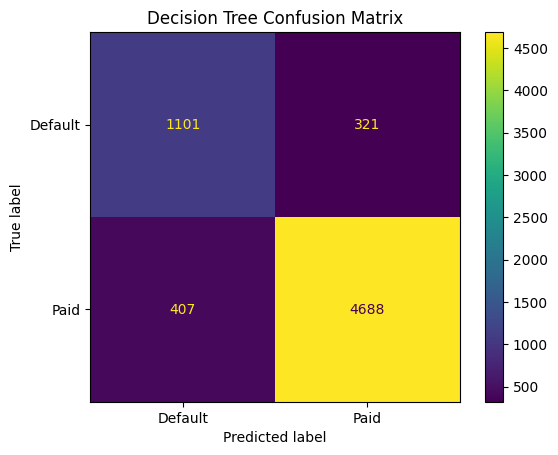

In [ ]:
predictions = tree_model.predict(X_test)
print("Predictions generated:", len(predictions))

# The class order printed here is the row/column order used in the confusion matrix.
labels = list(tree_model.classes_)
print("Class-label order:", labels)

# TODO 4.1: Fill in the two blanks with the actual test labels and predicted test labels.
cm = confusion_matrix(y_test, predictions, labels=labels)

print("\nConfusion matrix:")
print(cm)

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=labels
).plot()

plt.title("Decision Tree Confusion Matrix")
plt.show()
